# E-Commerce Customer Analytics - EDA

This notebook performs exploratory data analysis on the Online Retail II dataset.

Goals:
- Validate dataset quality
- Inspect customer and revenue patterns
- Build intuition for RFM clustering, CLV regression, and churn classification

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

PROJECT_ROOT = Path.cwd().parents[0]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data_preprocessing import load_raw_data, clean_transactions, preprocessing_summary

Matplotlib is building the font cache; this may take a moment.


In [ ]:
raw_path = PROJECT_ROOT / 'data' / 'online_retail_II.csv'
processed_path = PROJECT_ROOT / 'data' / 'processed_online_retail_II.csv'

raw_df = load_raw_data(raw_path)
clean_df = clean_transactions(raw_df)
summary_df = preprocessing_summary(raw_df, clean_df)

processed_path.parent.mkdir(parents=True, exist_ok=True)
clean_df.to_csv(processed_path, index=False)

summary_df

,raw_rows,clean_rows,rows_removed,unique_customers,date_min,date_max,total_revenue
0,1067371,805549,261822,5878,2009-12-01 07:45:00,2011-12-09 12:50:00,1.774343e+07


In [3]:
clean_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,CustomerID,TotalAmount
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,13085,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,13085,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,13085,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,13085,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,13085,30.0


In [4]:
clean_df.describe(include='all').transpose().head(20)

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Invoice,805549,36969,576339,542,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,805549,4631,85123A,5188,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,805549,5283,WHITE HANGING HEART T-LIGHT HOLDER,5181,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,805549.0,NaN,NaN,NaN,13.290522,1.0,2.0,5.0,12.0,80995.0,143.634088
InvoiceDate,805549,NaN,NaN,NaN,2011-01-02 10:24:44.106814464,2009-12-01 07:45:00,2010-07-07 12:08:00,2010-12-03 15:10:00,2011-07-28 13:05:00,2011-12-09 12:50:00,NaN
Price,805549.0,NaN,NaN,NaN,3.206561,0.001,1.25,1.95,3.75,10953.5,29.199173
Customer ID,805549.0,NaN,NaN,NaN,15331.95497,12346.0,13982.0,15271.0,16805.0,18287.0,1696.737039
Country,805549,41,United Kingdom,725250,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CustomerID,805549.0,NaN,NaN,NaN,15331.95497,12346.0,13982.0,15271.0,16805.0,18287.0,1696.737039
TotalAmount,805549.0,NaN,NaN,NaN,22.026505,0.001,4.95,11.85,19.5,168469.6,224.041928


In [5]:
missing = clean_df.isna().sum().sort_values(ascending=False)
missing[missing > 0]

Series([], dtype: int64)

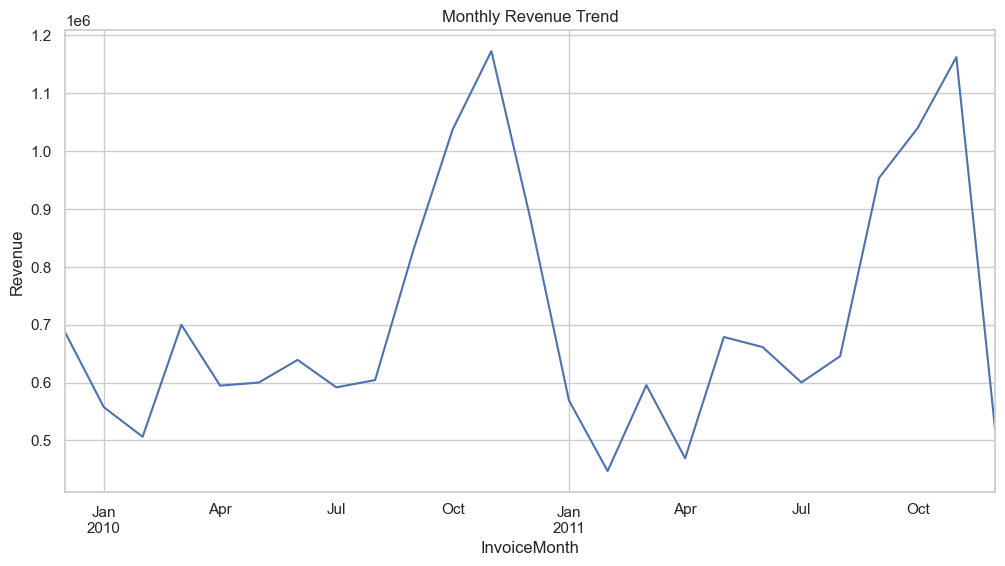

In [6]:
monthly_revenue = (
    clean_df.assign(InvoiceMonth=clean_df['InvoiceDate'].dt.to_period('M').dt.to_timestamp())
    .groupby('InvoiceMonth')['TotalAmount']
    .sum()
    .sort_index()
)

ax = monthly_revenue.plot(title='Monthly Revenue Trend')
ax.set_ylabel('Revenue')
plt.show()

/var/folders/qf/qnwqc5z97t513qlcfdthbhpc0000gn/T/ipykernel_92471/2676375821.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_countries, x='TotalAmount', y='Country', palette='viridis')


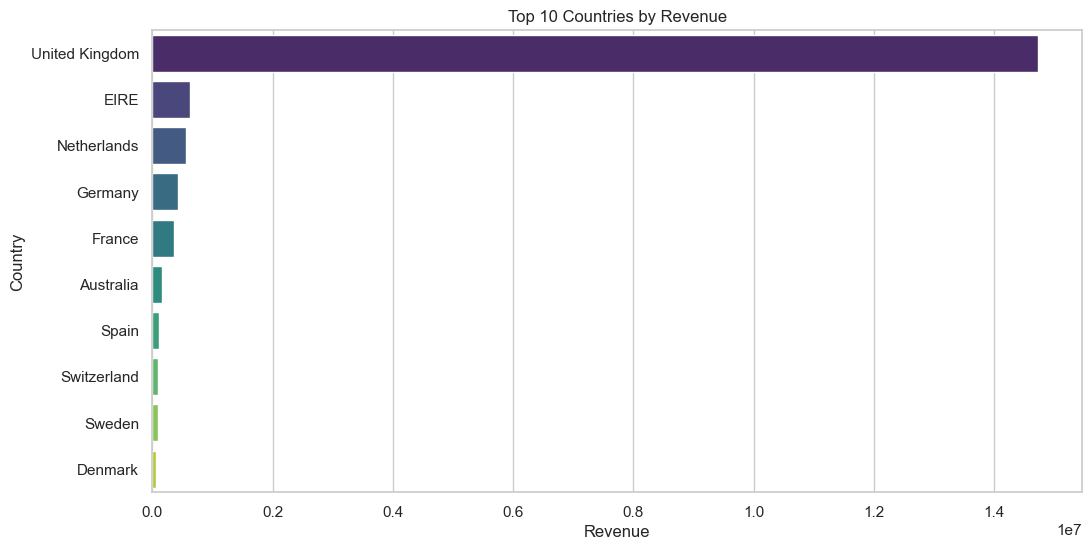

In [7]:
top_countries = (
    clean_df.groupby('Country', as_index=False)['TotalAmount']
    .sum()
    .sort_values('TotalAmount', ascending=False)
    .head(10)
)

sns.barplot(data=top_countries, x='TotalAmount', y='Country', palette='viridis')
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Country')
plt.show()

In [8]:
customer_stats = clean_df.groupby('CustomerID').agg(
    invoices=('Invoice', 'nunique'),
    avg_order_value=('TotalAmount', 'mean'),
    total_spend=('TotalAmount', 'sum'),
)

customer_stats.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
invoices,5878.0,6.289384,13.009406,1.000000,1.000000,3.000000,7.000000,398.00
avg_order_value,5878.0,48.299996,780.177864,2.042182,11.470705,17.354064,24.195021,56157.50
total_spend,5878.0,3018.616737,14737.731040,2.950000,348.762500,898.915000,2307.090000,608821.65


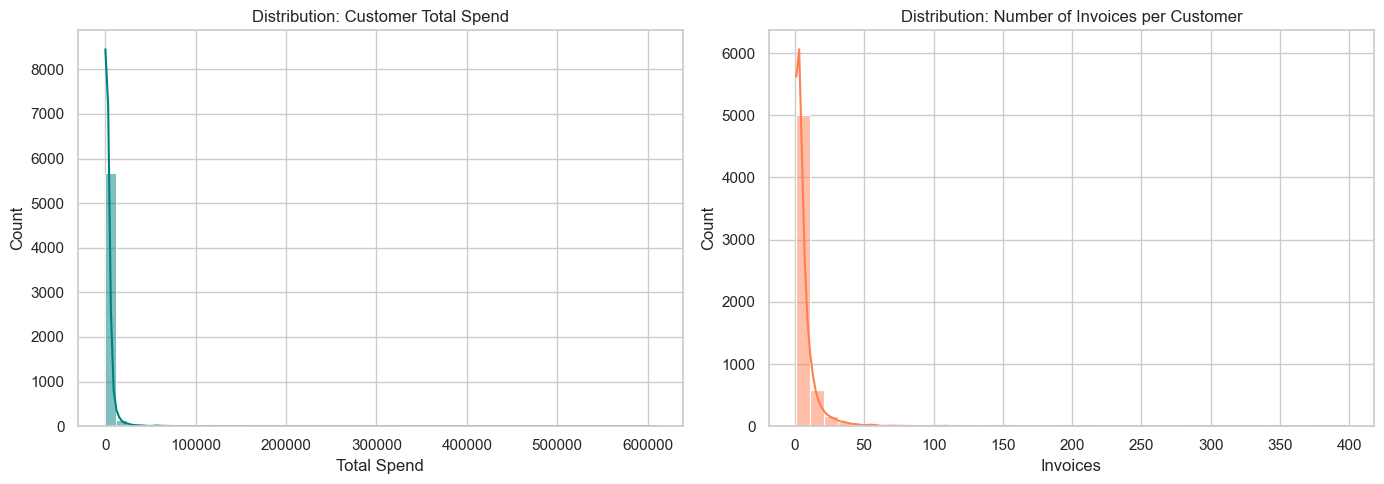

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(customer_stats['total_spend'], bins=50, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Distribution: Customer Total Spend')
axes[0].set_xlabel('Total Spend')

sns.histplot(customer_stats['invoices'], bins=40, kde=True, ax=axes[1], color='coral')
axes[1].set_title('Distribution: Number of Invoices per Customer')
axes[1].set_xlabel('Invoices')

plt.tight_layout()
plt.show()

## EDA Takeaways

- Revenue concentration by a subset of countries and customers suggests strong segmentation potential.
- Customer spend and purchase frequency are right-skewed, supporting robust scaling/modeling choices.
- Time trend reveals seasonality that can influence CLV and churn labeling windows.